In [1]:
!pip install torch torchvision
!pip install gradio
!pip install matplotlib seaborn scikit-learn
!pip install Pillow

In [2]:
import torch
import torchvision
import gradio
import matplotlib
import seaborn
import sklearn
from PIL import Image

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("All libraries loaded successfully! ✅")

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
All libraries loaded successfully! ✅


In [3]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:

TRAIN_DIR = r"C:\Users\lenovo\Downloads\archive\train"
TEST_DIR  = r"C:\Users\lenovo\Downloads\archive\test"


class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)

print(f"Total number of disease classes: {num_classes}")
print(f"\nAll classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

Total number of disease classes: 28

All classes:
  0: Apple_Scab_Leaf
  1: Apple_leaf
  2: Apple_rust_leaf
  3: Bell_pepper_leaf
  4: Bell_pepper_leaf_spot
  5: Blueberry_leaf
  6: Cherry_leaf
  7: Corn_Gray_leaf_spot
  8: Corn_leaf_blight
  9: Corn_rust_leaf
  10: Peach_leaf
  11: Potato_leaf_early_blight
  12: Potato_leaf_late_blight
  13: Raspberry_leaf
  14: Soyabean_leaf
  15: Squash_Powdery_mildew_leaf
  16: Strawberry_leaf
  17: Tomato_Early_blight_leaf
  18: Tomato_Septoria_leaf_spot
  19: Tomato_leaf
  20: Tomato_leaf_bacterial_spot
  21: Tomato_leaf_late_blight
  22: Tomato_leaf_mosaic_virus
  23: Tomato_leaf_yellow_virus
  24: Tomato_mold_leaf
  25: Tomato_two_spotted_spider_mites_leaf
  26: grape_leaf
  27: grape_leaf_black_rot


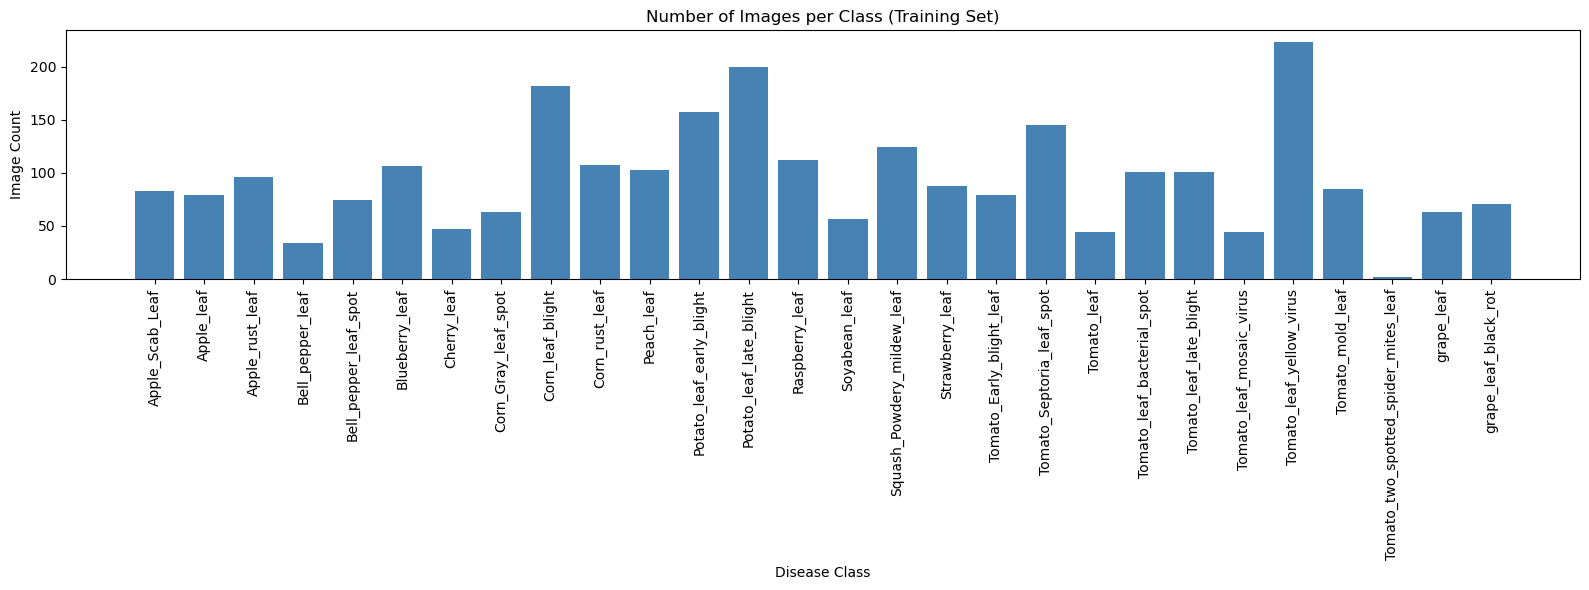


Total training images: 2670
Smallest class: Tomato_two_spotted_spider_mites_leaf (2 images)
Largest class:  Tomato_leaf_yellow_virus (223 images)


In [5]:

class_counts = {}
for class_name in class_names:
    path = os.path.join(TRAIN_DIR, class_name)
    count = len(os.listdir(path))
    class_counts[class_name] = count


plt.figure(figsize=(16, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.xticks(rotation=90)
plt.title("Number of Images per Class (Training Set)")
plt.xlabel("Disease Class")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

print(f"\nTotal training images: {sum(class_counts.values())}")
print(f"Smallest class: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())} images)")
print(f"Largest class:  {max(class_counts, key=class_counts.get)} ({max(class_counts.values())} images)")

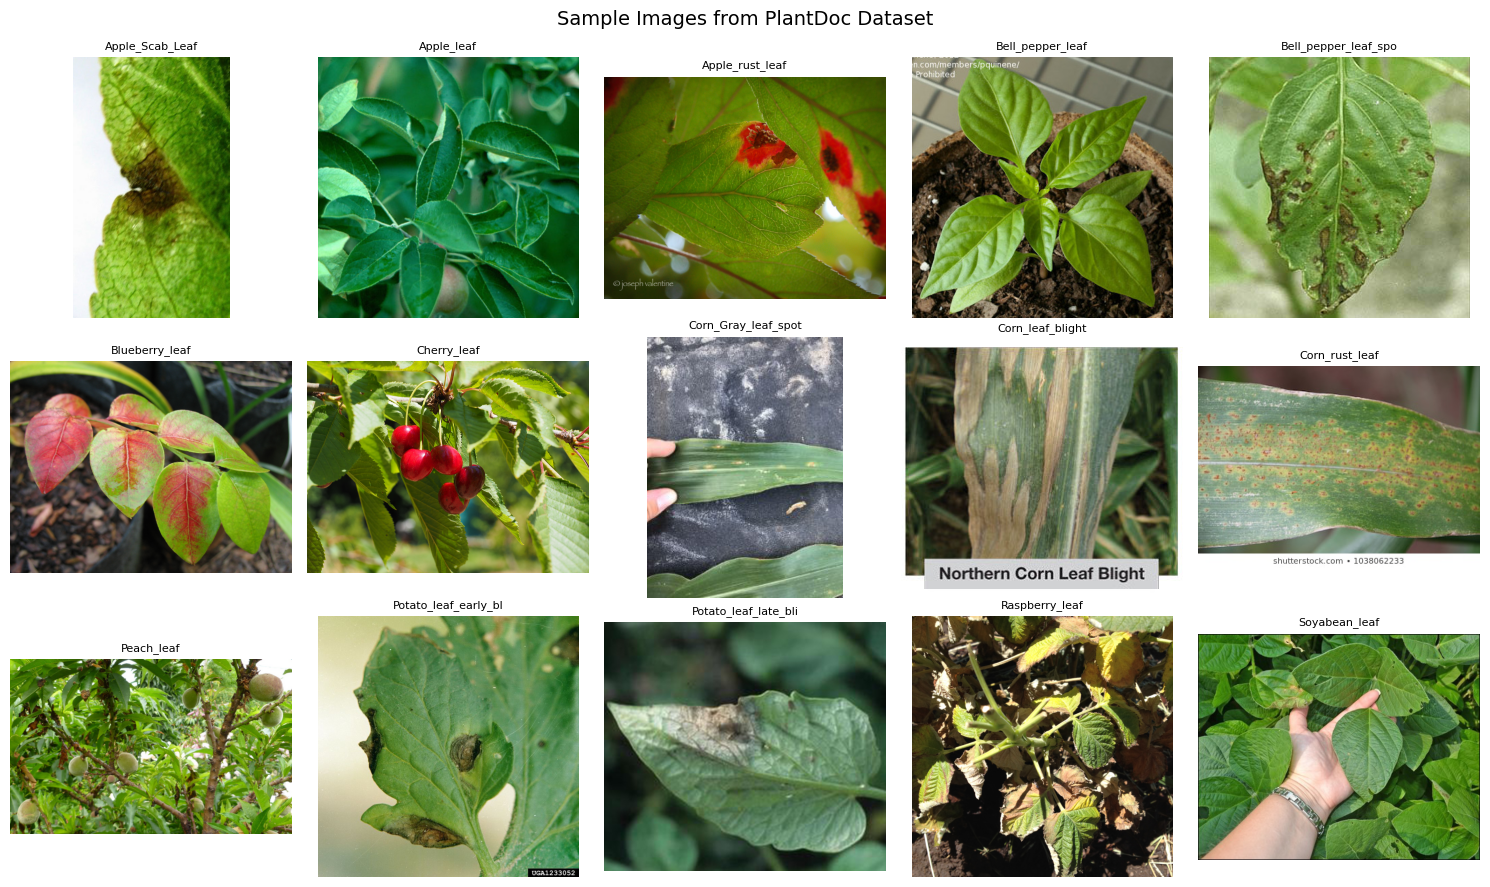

In [6]:

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, class_name in enumerate(class_names[:15]):
    class_path = os.path.join(TRAIN_DIR, class_name)
    img_file = os.listdir(class_path)[0]  # grab first image
    img_path = os.path.join(class_path, img_file)
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name[:20], fontsize=8)
    axes[i].axis('off')

plt.suptitle("Sample Images from PlantDoc Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
test_class_counts={}
for class_name in sorted(os.listdir(TEST_DIR)):
    path = os.path.join(TEST_DIR, class_name)
    if os.path.isdir(path):
        count = len(os.listdir(path))
        test_class_counts[class_name] = count

print(f"Total test images: {sum(test_class_counts.values())}")
print(f"Total test classes: {len(test_class_counts)}")

Total test images: 252
Total test classes: 27


In [8]:
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes  = sorted(os.listdir(TEST_DIR))

# Find the extra class
extra_in_train = set(train_classes) - set(test_classes)
extra_in_test  = set(test_classes) - set(train_classes)

print(f"Extra class in TRAIN (not in test): {extra_in_train}")
print(f"Extra class in TEST (not in train): {extra_in_test}")

Extra class in TRAIN (not in test): {'Tomato_two_spotted_spider_mites_leaf'}
Extra class in TEST (not in train): set()


In [10]:
from torchvision import transforms

IMG_SIZE = 300

# Training transforms — with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms ready ✅")

Transforms ready ✅


In [11]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

common_classes = sorted(set(os.listdir(TRAIN_DIR)) & set(os.listdir(TEST_DIR)))
print(f"Using {len(common_classes)} common classes ✅")


class FilteredImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform, valid_classes):
        super().__init__(root=root, transform=transform)
        # Keep only valid classes
        self.valid_classes = valid_classes
        self.class_to_idx = {cls: i for i, cls in enumerate(valid_classes)}
        self.samples = [
            (path, self.class_to_idx[cls])
            for path, _ in self.imgs
            for cls in [os.path.basename(os.path.dirname(path))]
            if cls in valid_classes
        ]
        self.targets = [s[1] for s in self.samples]


train_dataset = FilteredImageFolder(TRAIN_DIR, train_transforms, common_classes)
test_dataset  = FilteredImageFolder(TEST_DIR,  test_transforms,  common_classes)

print(f"Train images: {len(train_dataset)}")
print(f"Test images:  {len(test_dataset)}")
print(f"Classes: {train_dataset.classes[:5]}... (27 total)")

Using 27 common classes ✅
Train images: 2668
Test images:  252
Classes: ['Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Bell_pepper_leaf', 'Bell_pepper_leaf_spot']... (27 total)


In [12]:
total      = len(train_dataset)
train_size = int(0.8 * total)
val_size   = total - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training images:   {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Test images:       {len(test_dataset)}")

Training images:   2134
Validation images: 534
Test images:       252


In [13]:
BATCH_SIZE = 32

train_loader = DataLoader(train_data,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_data,      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Train batches:      67
Validation batches: 17
Test batches:       8


In [14]:
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")
print(f"Min pixel value: {images.min():.3f}")
print(f"Max pixel value: {images.max():.3f}")

Batch image shape: torch.Size([32, 3, 300, 300])
Batch labels shape: torch.Size([32])
Min pixel value: -2.118
Max pixel value: 2.640


In [15]:
import torchvision.models as models
import torch.nn as nn

def build_model(num_classes, device):
    
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

    
    for param in model.parameters():
        param.requires_grad = False

    
    in_features = model.classifier[1].in_features  
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )

    return model.to(device)

# Build it
NUM_CLASSES = len(common_classes)  # 27
model = build_model(NUM_CLASSES, device)
print(f"Model built successfully! ✅")
print(f"Output classes: {NUM_CLASSES}")
print(f"Running on: {device}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to C:\Users\lenovo/.cache\torch\hub\checkpoints\efficientnet_b3_rwightman-b3899882.pth


100%|█████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:02<00:00, 19.3MB/s]


Model built successfully! ✅
Output classes: 27
Running on: cpu


In [16]:

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"\nOnly {trainable_params/total_params*100:.1f}% of parameters will be trained")

Total parameters:     11,497,027
Trainable parameters: 800,795
Frozen parameters:    10,696,232

Only 7.0% of parameters will be trained


In [19]:

criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

print("Loss function, optimizer and scheduler ready ✅")

Loss function, optimizer and scheduler ready ✅


In [22]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=20):
    
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
         
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            # Move data to device (GPU or CPU)
            images = images.to(device)
            labels = labels.to(device)

            # 1. Clear old gradients
            optimizer.zero_grad()

            # 2. Forward pass — model makes predictions
            outputs = model(images)

            # 3. Calculate loss — how wrong are the predictions?
            loss = criterion(outputs, labels)

            # 4. Backward pass — calculate gradients
            loss.backward()

            # 5. Update weights
            optimizer.step()

            # Track statistics
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

            # Print progress every 20 batches
            if (batch_idx + 1) % 20 == 0:
                print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

       
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # Don't calculate gradients during validation
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        # Calculate epoch statistics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)
        train_acc      = 100. * train_correct / train_total
        val_acc        = 100. * val_correct   / val_total

        # Save to history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Step scheduler
        scheduler.step(avg_val_loss)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  💾 Best model saved! Val Acc: {val_acc:.2f}%")

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print("-" * 55)

    print(f"\n✅ Training complete! Best Validation Accuracy: {best_val_acc:.2f}%")
    return history

In [23]:
print("🚀 Starting training...")
print(f"Device: {device}")
print(f"Epochs: 20")
print(f"Batch size: 32")
print(f"Train batches per epoch: {len(train_loader)}")
print("=" * 55)

history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    epochs=20
)

🚀 Starting training...
Device: cpu
Epochs: 20
Batch size: 32
Train batches per epoch: 67
  Epoch 1 | Batch 20/67 | Loss: 2.6043
  Epoch 1 | Batch 40/67 | Loss: 2.4845
  Epoch 1 | Batch 60/67 | Loss: 2.3280
  💾 Best model saved! Val Acc: 45.69%

Epoch 1/20
  Train Loss: 2.5550 | Train Acc: 28.77%
  Val Loss:   1.9232 | Val Acc:   45.69%
-------------------------------------------------------
  Epoch 2 | Batch 20/67 | Loss: 1.8967
  Epoch 2 | Batch 40/67 | Loss: 1.5368
  Epoch 2 | Batch 60/67 | Loss: 1.5561
  💾 Best model saved! Val Acc: 53.00%

Epoch 2/20
  Train Loss: 1.7079 | Train Acc: 47.05%
  Val Loss:   1.5492 | Val Acc:   53.00%
-------------------------------------------------------
  Epoch 3 | Batch 20/67 | Loss: 1.6935
  Epoch 3 | Batch 40/67 | Loss: 1.3470
  Epoch 3 | Batch 60/67 | Loss: 1.7455
  💾 Best model saved! Val Acc: 56.55%

Epoch 3/20
  Train Loss: 1.4947 | Train Acc: 54.17%
  Val Loss:   1.3865 | Val Acc:   56.55%
----------------------------------------------------

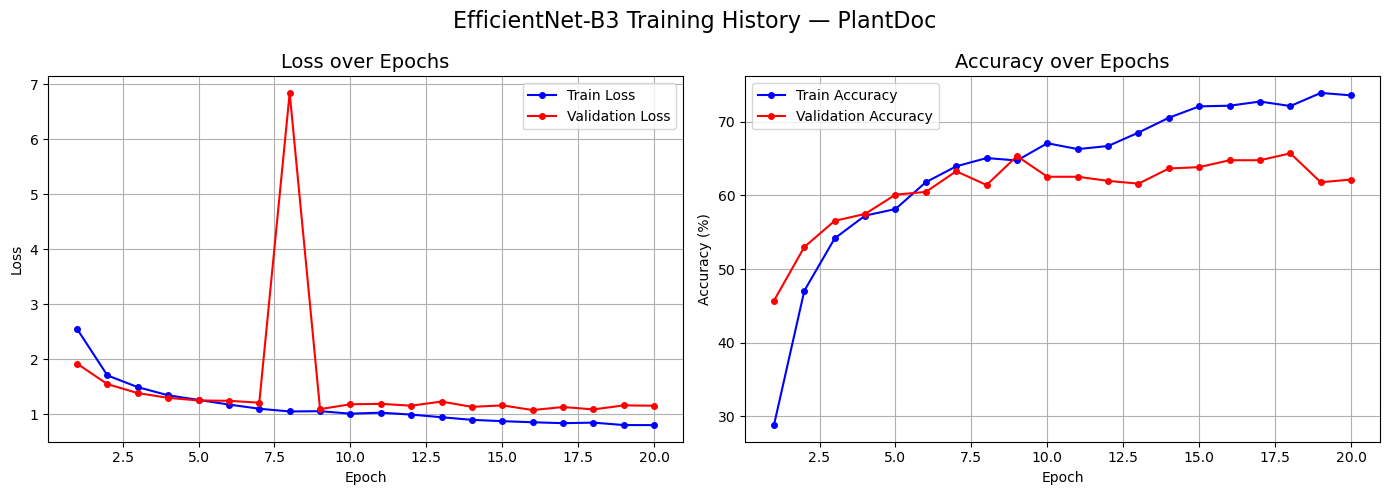

Plot saved as training_curves.png ✅


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss',      markersize=4)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', markersize=4)
ax1.set_title('Loss over Epochs',    fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy',      markersize=4)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', markersize=4)
ax2.set_title('Accuracy over Epochs', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('EfficientNet-B3 Training History — PlantDoc', fontsize=16)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as training_curves.png ✅")

In [25]:
# Load the BEST saved model (not the last one)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

test_correct = 0
test_total   = 0
all_preds    = []
all_labels   = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs   = model(images)
        _, predicted = outputs.max(1)

        test_total   += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. * test_correct / test_total
print(f"✅ Final Test Accuracy: {test_acc:.2f}%")
print(f"   Correct: {test_correct}/{test_total}")

✅ Final Test Accuracy: 54.37%
   Correct: 137/252


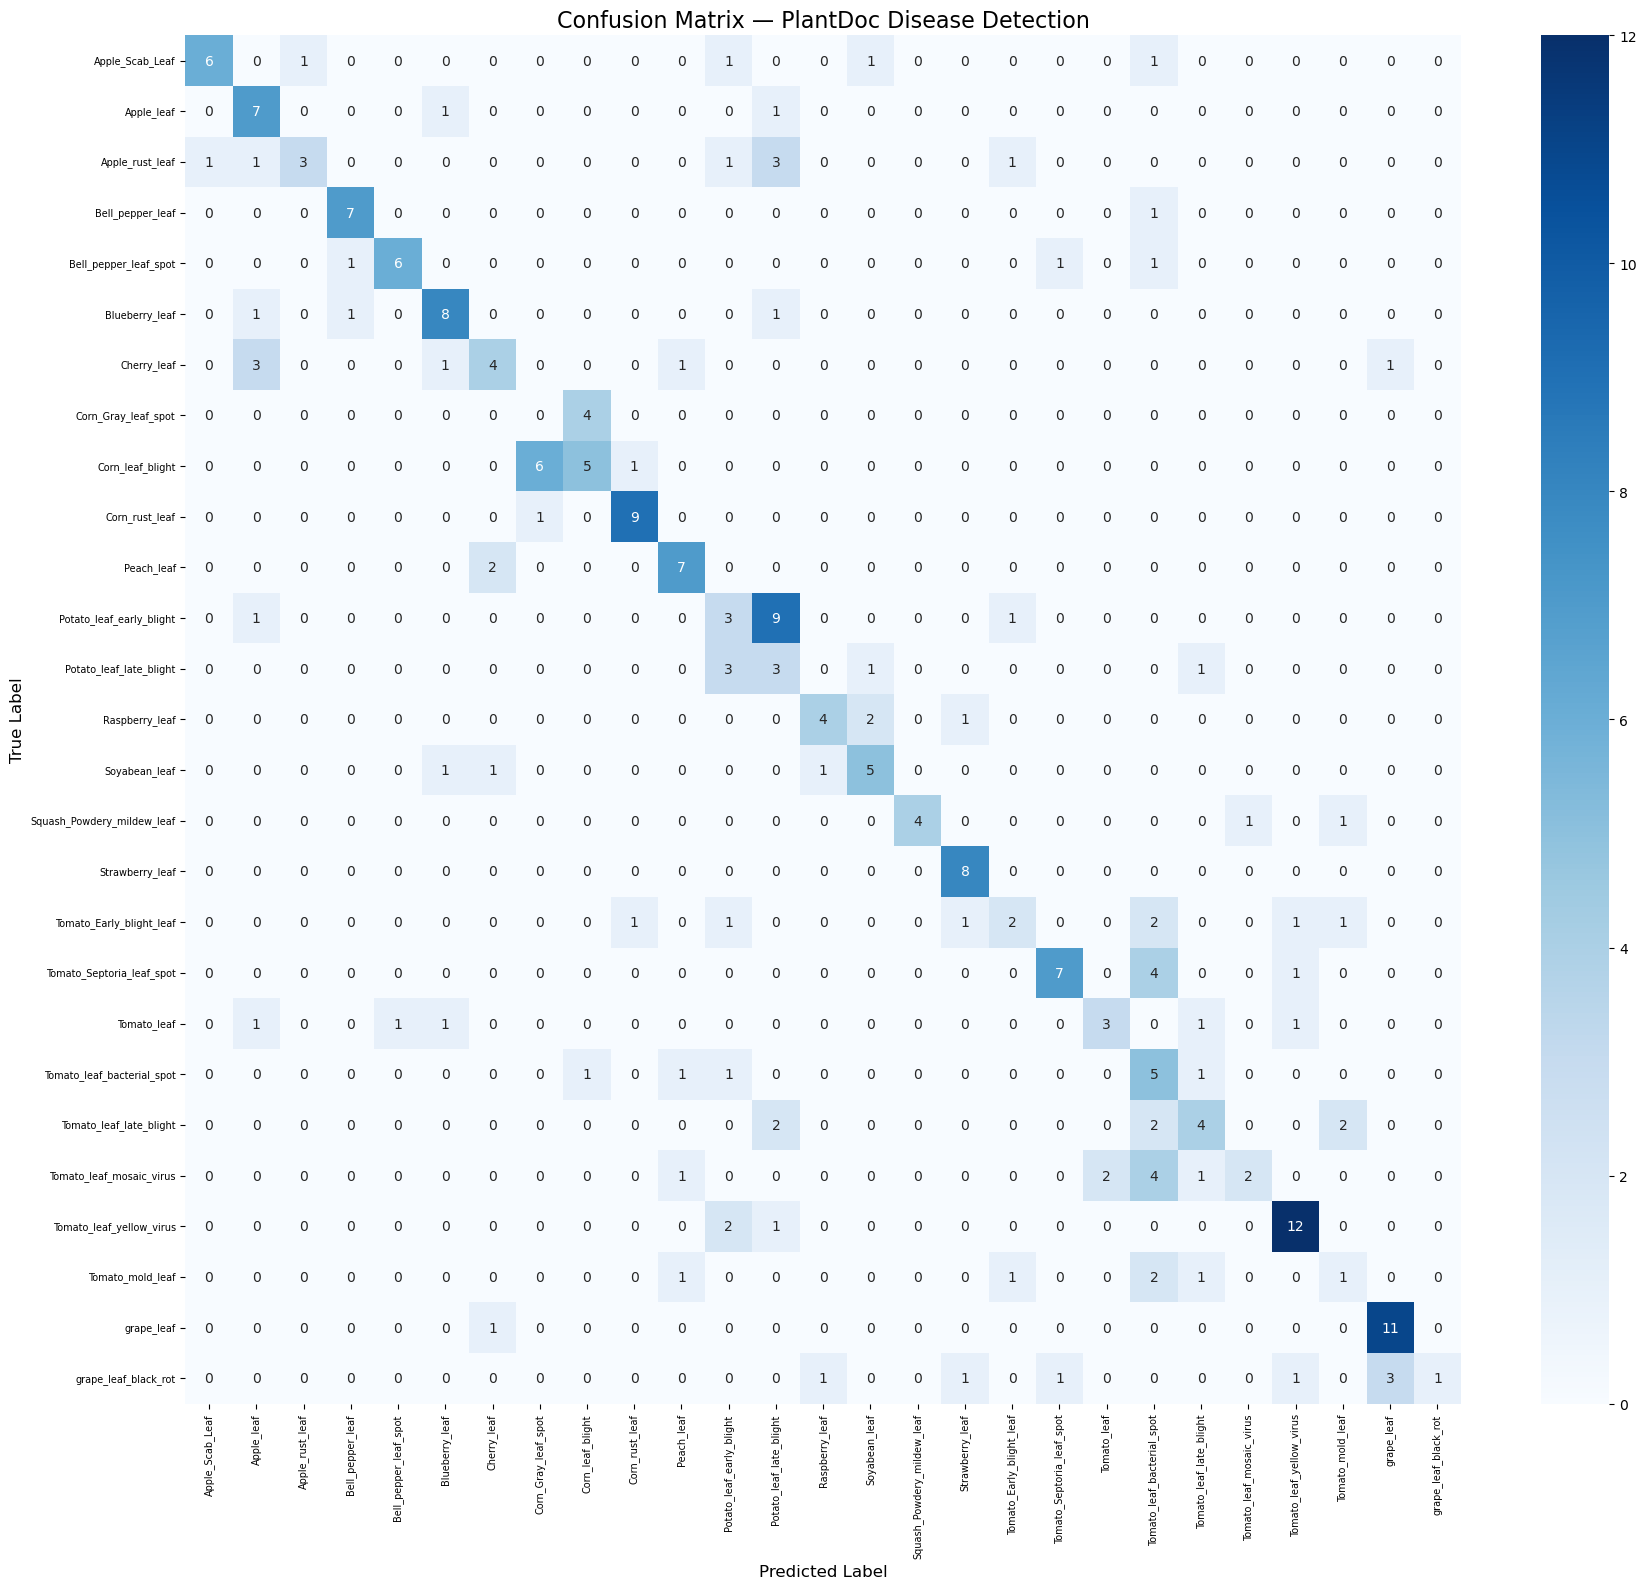


Classification Report:
                            precision    recall  f1-score   support

           Apple_Scab_Leaf       0.86      0.60      0.71        10
                Apple_leaf       0.50      0.78      0.61         9
           Apple_rust_leaf       0.75      0.30      0.43        10
          Bell_pepper_leaf       0.78      0.88      0.82         8
     Bell_pepper_leaf_spot       0.86      0.67      0.75         9
            Blueberry_leaf       0.67      0.73      0.70        11
               Cherry_leaf       0.50      0.40      0.44        10
       Corn_Gray_leaf_spot       0.00      0.00      0.00         4
          Corn_leaf_blight       0.50      0.42      0.45        12
            Corn_rust_leaf       0.82      0.90      0.86        10
                Peach_leaf       0.64      0.78      0.70         9
  Potato_leaf_early_blight       0.25      0.21      0.23        14
   Potato_leaf_late_blight       0.15      0.38      0.21         8
            Raspberry_l

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=common_classes,
    yticklabels=common_classes
)
plt.title('Confusion Matrix — PlantDoc Disease Detection', fontsize=16)
plt.ylabel('True Label',      fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=common_classes))

In [27]:
from sklearn.metrics import classification_report
import pandas as pd

# Get test accuracy clearly
print(f"{'='*50}")
print(f"  FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"{'='*50}")

# Per class accuracy — easy to read
report = classification_report(all_labels, all_preds, 
                                target_names=common_classes, 
                                output_dict=True)

# Convert to dataframe and sort by f1-score
df_report = pd.DataFrame(report).transpose()
df_report = df_report[:-3]  # remove avg rows
df_report = df_report.sort_values('f1-score', ascending=False)

print("\n📊 Top 5 Best Detected Diseases:")
print(df_report[['precision','recall','f1-score','support']].head(5).round(2))

print("\n📊 Bottom 5 Hardest Diseases:")
print(df_report[['precision','recall','f1-score','support']].tail(5).round(2))

  FINAL TEST ACCURACY: 54.37%

📊 Top 5 Best Detected Diseases:
                            precision  recall  f1-score  support
Corn_rust_leaf                   0.82    0.90      0.86     10.0
Strawberry_leaf                  0.73    1.00      0.84      8.0
Bell_pepper_leaf                 0.78    0.88      0.82      8.0
grape_leaf                       0.73    0.92      0.81     12.0
Squash_Powdery_mildew_leaf       1.00    0.67      0.80      6.0

📊 Bottom 5 Hardest Diseases:
                          precision  recall  f1-score  support
Potato_leaf_early_blight       0.25    0.21      0.23     14.0
grape_leaf_black_rot           1.00    0.12      0.22      8.0
Potato_leaf_late_blight        0.15    0.38      0.21      8.0
Tomato_mold_leaf               0.20    0.17      0.18      6.0
Corn_Gray_leaf_spot            0.00    0.00      0.00      4.0
